# Projection Manager Physical Calibration

Guarded end-to-end calibration of the physical DMD against the PVCAM camera. The notebook connects SyncBoard illumination, an optional ASI Tiger filter wheel, and the EM Window DMD; scans calibration points; saves the correspondence pickle; reloads it as `DmdCalibrationData`; checks the resulting homographies; and safely cleans up all devices.

In [15]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from contextlib import suppress
from dataclasses import dataclass
from pathlib import Path
import os
import pickle
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "evomachine" / "projection.py").is_file():
            return candidate
    raise RuntimeError("Could not find the EvoMachine repository root.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np

from evomachine.bindings.binding_types import BindingType
from evomachine.bindings.em_dmd_window.peripheralcontroller import EmDmdWindowPeripheralController
from evomachine.peripherals.camera import CameraConfig, CameraFactory, ImageConfigType
from evomachine.peripherals.dmd import DmdCalibrationConfig, DmdConfig, DmdFactory
from evomachine.peripherals.filterwheel import FilterWheelConfig, FilterWheelFactory
from evomachine.peripherals.leds import LedConfig, LedFactory, LedManager
from evomachine.peripherals.peripheralcontrollers import (
    PeripheralControllerFactory,
    SerialPeripheralControllerConfig,
)
from evomachine.projection import ProjectionManager
from evomachine.types import FilterWheelType, LEDType

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Review physical settings

Start with a coarse grid and conservative exposure. Close Micro-Manager before enabling the run. The output file is protected from accidental overwrite by a separate switch.

In [19]:
@dataclass(frozen=True, kw_only=True)
class PhysicalProjectionSettings:
    camera_width: int = 3200
    camera_height: int = 3200
    camera_timeout_ms: int = 5000
    syncboard_hwid: str = "USB VID:PID=16C0:0483 SER=14582700 LOCATION=7-2:1.0"
    tiger_hwid: str = "USB VID:PID=10C4:EA60 SER=0001 LOCATION=5-3"
    use_filter_wheel: bool = True
    filter_card_address: int = 8
    calibration_filter: FilterWheelType = FilterWheelType.FILTER_527nm
    restore_filter: FilterWheelType = FilterWheelType.FILTER
    led: LEDType = LEDType.LED_515_NM
    brightness: float = 15
    exposure_ms: int = 100
    point_radius: int = 5
    point_delay_s: float = 0.5
    grid_step: int = 300
    start_row: int = 200
    end_row: int = 2500
    start_col: int = 0
    end_col: int = 1599
    on_mothermachine: bool = True
    dmd_size: tuple[int, int] = (2716, 1600)
    existing_calibration_file: Path = REPO_ROOT / "evomachine" / "dmd_calibration_data.pkl"
    output_file = Path("/tmp/dmd_calibration_projection_manager_test2.pkl")


SETTINGS = PhysicalProjectionSettings()
RUN_PHYSICAL_CALIBRATION = True
ALLOW_OVERWRITE = False
SETTINGS

PhysicalProjectionSettings(camera_width=3200, camera_height=3200, camera_timeout_ms=5000, syncboard_hwid='USB VID:PID=16C0:0483 SER=14582700 LOCATION=7-2:1.0', tiger_hwid='USB VID:PID=10C4:EA60 SER=0001 LOCATION=5-3', use_filter_wheel=True, filter_card_address=8, calibration_filter=<FilterWheelType.FILTER_527nm: 2>, restore_filter=<FilterWheelType.FILTER: 0>, led=<LEDType.LED_515_NM: 2>, brightness=15, exposure_ms=100, point_radius=5, point_delay_s=0.5, grid_step=300, start_row=200, end_row=2500, start_col=0, end_col=1599, on_mothermachine=True, dmd_size=(2716, 1600), existing_calibration_file=PosixPath('/home/hslab/workspace_python/evomachine_refactor/evomachine/evomachine/dmd_calibration_data.pkl'))

## Preflight

This cell performs no hardware actions. Confirm paths, estimated point count, and run guards before continuing.

In [20]:
calibration_config = DmdCalibrationConfig(
    channel=SETTINGS.led,
    brightness=SETTINGS.brightness,
    exposure=SETTINGS.exposure_ms,
    line_width=SETTINGS.point_radius,
    step=SETTINGS.grid_step,
    delay=SETTINGS.point_delay_s,
    start_row=SETTINGS.start_row,
    end_row=SETTINGS.end_row,
    start_col=SETTINGS.start_col,
    end_col=SETTINGS.end_col,
    on_mothermachine=SETTINGS.on_mothermachine,
)
estimated_rows = len(range(SETTINGS.start_row, SETTINGS.end_row + SETTINGS.grid_step, SETTINGS.grid_step))
estimated_cols = len(range(SETTINGS.start_col, SETTINGS.end_col + SETTINGS.grid_step, SETTINGS.grid_step))
em_window_program = REPO_ROOT.parent / "em_dmd_window" / "Release" / "evomachine_dmd_window"
{
    "run_enabled": RUN_PHYSICAL_CALIBRATION,
    "output_file": SETTINGS.output_file,
    "output_exists": SETTINGS.output_file.exists(),
    "existing_calibration_exists": SETTINGS.existing_calibration_file.exists(),
    "em_window_program_exists": em_window_program.exists(),
    "estimated_grid_points": estimated_rows * estimated_cols,
    "config": calibration_config,
}

{'run_enabled': True,
 'output_file': PosixPath('/tmp/dmd_calibration_projection_manager_test2.pkl'),
 'output_exists': False,
 'existing_calibration_exists': True,
 'em_window_program_exists': True,
 'estimated_grid_points': 63,
 'config': DmdCalibrationConfig(channel=<LEDType.LED_515_NM: 2>, brightness=15, exposure=100, line_width=5, step=300, delay=0.5, start_row=200, end_row=2500, start_col=0, end_col=1599, on_mothermachine=True)}

## Open calibration hardware

This cell claims the camera and serial ports, launches the EM DMD window, blanks illumination, and creates `ProjectionManager`. Re-running it first cleans up objects from its previous run.

In [21]:
if not RUN_PHYSICAL_CALIBRATION:
    raise RuntimeError("Review settings, close Micro-Manager, then set RUN_PHYSICAL_CALIBRATION=True.")
if SETTINGS.output_file.exists() and not ALLOW_OVERWRITE:
    raise FileExistsError(f"Refusing to overwrite {SETTINGS.output_file}; choose a new path or enable ALLOW_OVERWRITE.")
if not 0 <= SETTINGS.brightness <= 29:
    raise ValueError("SyncBoard calibration brightness must be in [0, 29].")

for name in ("projection_dmd", "projection_filter_wheel", "projection_camera", "projection_led_manager"):
    device = globals().get(name)
    if device is not None and device.is_initialised():
        with suppress(Exception):
            device.stop()
        with suppress(Exception):
            device.finalise()
for name in ("syncboard_controller", "tiger_controller", "dmd_controller"):
    controller = globals().get(name)
    if controller is not None and controller.is_initialised():
        with suppress(Exception):
            controller.shutdown()

syncboard_controller = tiger_controller = dmd_controller = None
projection_camera = projection_led_manager = projection_filter_wheel = projection_dmd = None
try:
    syncboard_controller = PeripheralControllerFactory.create(
        SerialPeripheralControllerConfig(binding=BindingType.SYNCBOARD, hwid=SETTINGS.syncboard_hwid)
    )
    led_source = LedFactory.create(
        LedConfig(binding=BindingType.SYNCBOARD, available_leds=[SETTINGS.led]),
        peripheral_controllers=syncboard_controller,
    )
    projection_led_manager = LedManager([led_source], name="Projection LED Manager")
    projection_led_manager.initialise()
    projection_led_manager.disable_led()

    projection_camera = CameraFactory.create(
        CameraConfig(
            binding=BindingType.PVCAM,
            image=ImageConfigType(
                pxl_horiz=SETTINGS.camera_width,
                pxl_vert=SETTINGS.camera_height,
                pxl_dtype=np.dtype("uint16"),
            ),
            default_exposure_time=SETTINGS.exposure_ms,
        ),
        frame_timeout_ms=SETTINGS.camera_timeout_ms,
    )
    projection_camera.initialise()

    if SETTINGS.use_filter_wheel:
        tiger_controller = PeripheralControllerFactory.create(
            SerialPeripheralControllerConfig(binding=BindingType.ASI_TIGER, hwid=SETTINGS.tiger_hwid),
            card_address_filter_wheel=SETTINGS.filter_card_address,
        )
        projection_filter_wheel = FilterWheelFactory.create(
            FilterWheelConfig(
                binding=BindingType.ASI_TIGER,
                available_filters=[SETTINGS.calibration_filter, SETTINGS.restore_filter],
            ),
            peripheral_controllers=tiger_controller,
        )
        projection_filter_wheel.initialise()
        projection_filter_wheel.set_filter_wheel(SETTINGS.restore_filter, force=True)

    dmd_controller = EmDmdWindowPeripheralController(debug_mode=False)
    projection_dmd = DmdFactory.create(
        DmdConfig(
            binding=BindingType.EM_DMD_WINDOW,
            width_height_DMD=SETTINGS.dmd_size,
            width_height_CAM=(SETTINGS.camera_width, SETTINGS.camera_height),
            calibration_file=SETTINGS.existing_calibration_file,
        ),
        peripheral_controllers=dmd_controller,
    )
    projection_dmd.initialise()
    projection_dmd.display_none()

    projection_manager = ProjectionManager(
        camera=projection_camera,
        dmd=projection_dmd,
        led_manager=projection_led_manager,
        filter_wheel=projection_filter_wheel,
        calibration_directory=SETTINGS.output_file.parent,
    )
except Exception:
    if projection_led_manager is not None:
        with suppress(Exception): projection_led_manager.disable_led()
    if projection_dmd is not None:
        with suppress(Exception): projection_dmd.display_none()
    for device in (projection_dmd, projection_filter_wheel, projection_camera, projection_led_manager):
        if device is not None:
            with suppress(Exception): device.finalise()
    for controller in (dmd_controller, tiger_controller, syncboard_controller):
        if controller is not None:
            with suppress(Exception): controller.shutdown()
    raise

{
    "devices_ready": projection_manager.devices_are_initialised(),
    "camera_alive": projection_camera.is_alive(),
    "dmd_alive": projection_dmd.is_alive(),
    "filter_before_calibration": (
        projection_filter_wheel.get_filter_wheel() if projection_filter_wheel is not None else None
    ),
}

2026-07-02 17:17:20 - DEBUG - syncboard.serialconnection - Connecting to /dev/ttyACM0 at 2000000 baud
2026-07-02 17:17:20 - DEBUG - syncboard.serialconnection - Connecting to /dev/ttyACM0 at 2000000 baud
2026-07-02 17:17:20 - DEBUG - syncboard.command - Formatted command: $attachLED/true#%
2026-07-02 17:17:20 - DEBUG - syncboard.command - Formatted command: $attachLED/true#%
2026-07-02 17:17:20 - DEBUG - syncboard.syncboardcontroller - Sending command $attachLED/true#% at attempt 0.
2026-07-02 17:17:20 - DEBUG - syncboard.syncboardcontroller - Sending command $attachLED/true#% at attempt 0.
2026-07-02 17:17:20 - DEBUG - syncboard.serialconnection - Sending data: b'$attachLED/true#%'
2026-07-02 17:17:20 - DEBUG - syncboard.serialconnection - Sending data: b'$attachLED/true#%'
2026-07-02 17:17:20 - DEBUG - syncboard.serialconnection - Received: $attachLED/1#%

2026-07-02 17:17:20 - DEBUG - syncboard.serialconnection - Received: $attachLED/1#%

2026-07-02 17:17:20 - DEBUG - syncboard.seri

{'devices_ready': True,
 'camera_alive': True,
 'dmd_alive': True,
 'filter_before_calibration': <FilterWheelType.FILTER: 0>}

## Run physical calibration

Keep the optical path unobstructed. Calibration automatically disables camera live mode, sets illumination and filter, scans the grid, saves the pickle, loads `DmdCalibrationData`, computes homographies, restores the previous filter, disables LEDs, and blanks the DMD in a `finally` block.

In [24]:
if not RUN_PHYSICAL_CALIBRATION:
    raise RuntimeError("Physical calibration is disabled.")
if not projection_manager.devices_are_initialised():
    raise RuntimeError("Run the hardware setup cell first.")

projection_manager.dmd_calibrate(
    cfg=calibration_config,
    filename=SETTINGS.output_file,
)
if not SETTINGS.output_file.exists():
    raise RuntimeError("Calibration did not produce an output file; inspect the intensity logs.")

with SETTINGS.output_file.open("rb") as calibration_file:
    stored_records = pickle.load(calibration_file)
if projection_dmd._calib_data is None:
    raise RuntimeError("DMD did not load the saved calibration data.")
if len(stored_records) < 4:
    raise RuntimeError(f"Only {len(stored_records)} calibration points were detected; at least four are required.")

{
    "saved_to": SETTINGS.output_file,
    "saved_bytes": SETTINGS.output_file.stat().st_size,
    "detected_points": len(stored_records),
    "calibration_data_type": type(projection_dmd._calib_data).__name__,
    "homography": projection_dmd._homography_mat,
    "inverse_homography": projection_dmd._homography_mat_inv,
    "filter_after_calibration": (
        projection_filter_wheel.get_filter_wheel() if projection_filter_wheel is not None else None
    ),
}

INFO:evomachine.projection:ProjectionManager.dmd_calibrate: starting with config DmdCalibrationConfig
 ├─ channel: LED_515_NM
 ├─ brightness: 15
 ├─ exposure: 100
 ├─ line_width: 5
 ├─ step: 300
 ├─ delay: 0.5
 ├─ start_row: 200
 ├─ end_row: 2500
 ├─ start_col: 0
 ├─ end_col: 1599
 └─ on_mothermachine: True and filename /tmp/dmd_calibration_projection_manager_test2.pkl.
2026-07-02 17:18:11 - DEBUG - evomachine.peripherals.camera - Camera.disable_live_mode: disabling live mode for PVCAM Camera.
2026-07-02 17:18:11 - DEBUG - evomachine.peripherals.camera - Camera.set_exposure: setting PVCAM Camera exposure to 100 ms.
2026-07-02 17:18:11 - DEBUG - evomachine.peripherals.leds - LedManager.set_led: routing LED_515_NM brightness=15 duration=None through Projection LED Manager.
2026-07-02 17:18:11 - DEBUG - evomachine.peripherals.leds - LedSource.set_led: setting SyncBoard LED Source LED_515_NM to brightness=15.0 duration=None.
2026-07-02 17:18:11 - DEBUG - syncboard.syncboardcontroller - LED

{'saved_to': PosixPath('/tmp/dmd_calibration_projection_manager_test2.pkl'),
 'saved_bytes': 2312,
 'detected_points': 62,
 'calibration_data_type': 'DmdCalibrationData',
 'homography': array([[-1.33473421e-01, -1.81899955e+00,  9.00140706e+02],
        [-1.90442524e-01, -2.81025113e+00,  1.34881684e+03],
        [-1.40611801e-04, -2.06009859e-03,  1.00000000e+00]]),
 'inverse_homography': array([[-7.39206664e-01, -1.00089266e+00,  1.55136159e+03],
        [-1.54085476e-01, -1.99047629e-01,  3.18905696e+02],
        [-4.75402737e-04, -6.46255552e-04,  1.00000000e+00]]),
 'filter_after_calibration': <FilterWheelType.FILTER: 0>}

## Inspect calibration error

Transform every detected camera point back into DMD coordinates and report pixel error relative to its requested DMD point. This is a numerical sanity check; visual projection onto the specimen remains the final physical validation.

In [25]:
errors = []
for (dmd_row, dmd_col), (cam_row, cam_col), _ in stored_records:
    predicted_row, predicted_col = projection_dmd.img_to_dmd_coords(cam_row, cam_col)
    errors.append(float(np.hypot(predicted_row - dmd_row, predicted_col - dmd_col)))
errors = np.asarray(errors)
{
    "mean_error_px": float(errors.mean()),
    "median_error_px": float(np.median(errors)),
    "max_error_px": float(errors.max()),
    "point_count": int(errors.size),
}

{'mean_error_px': 890.2917611308549,
 'median_error_px': 895.5347404159627,
 'max_error_px': 1591.22719936532,
 'point_count': 62}

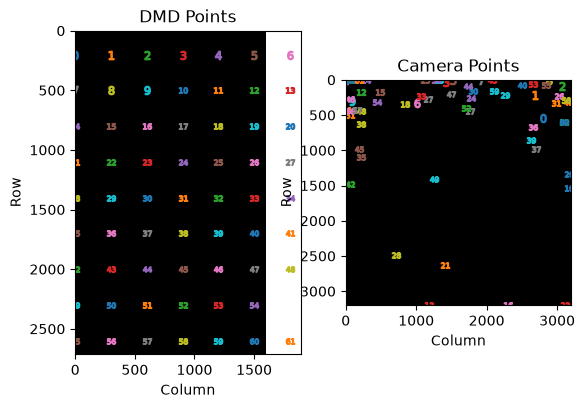

In [27]:
from matplotlib import pyplot as plt
data = stored_records
DMD_WIDTH_HEIGHT = (2716, 1600)
CAM_WIDTH_HEIGHT = (3200, 3200)
dmd_img = np.ones(DMD_WIDTH_HEIGHT, dtype=np.uint8) * 100
cam_img = np.ones(CAM_WIDTH_HEIGHT, dtype=np.uint8) * 100
fig, axs = plt.subplots(1, 2)
axs[0].imshow(dmd_img, cmap='gray')
axs[1].imshow(cam_img, cmap='gray')
for i, ((r_dmd, c_dmd), (r_cam, c_cam), _) in enumerate(data):
    marker = str(i)
    _ = axs[0].scatter(c_dmd, r_dmd, marker='$' + marker + '$')
    _ = axs[0].set_title('DMD Points')
    _ = axs[0].set_xlabel('Column')
    _ = axs[0].set_ylabel('Row')
    _ = axs[1].scatter(c_cam, r_cam, marker='$' + marker + '$')
    _ = axs[1].set_title('Camera Points')
    _ = axs[1].set_xlabel('Column')
    _ = axs[1].set_ylabel('Row')

Text(0.5, 1.0, 'DMD Image')

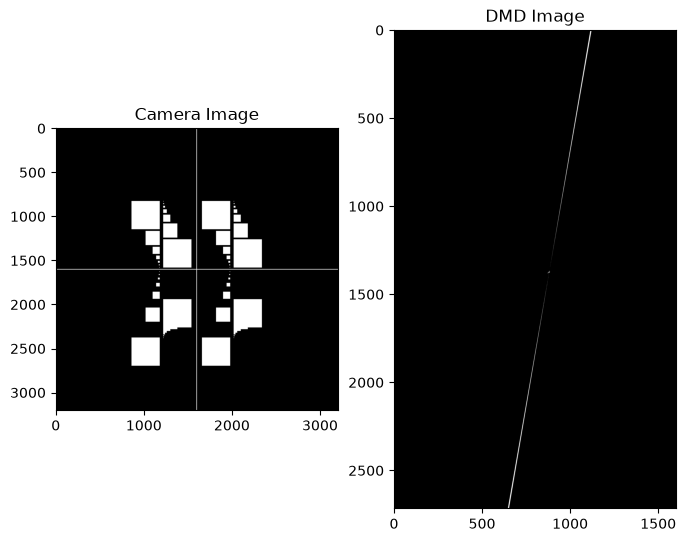

In [26]:
from matplotlib import pyplot as plt

cam_img = projection_dmd.get_calibration_image(img_size=(3200, 3200))
dmd_img = projection_dmd.img_to_dmd_array(cam_img)

fig, ax = plt.subplots(1,2,figsize=(8, 8))
ax[0].imshow(cam_img, cmap="gray")
ax[0].set_title("Camera Image")
ax[1].imshow(dmd_img, cmap="gray")
ax[1].set_title("DMD Image")

## Cleanup

Always run this before unplugging hardware or closing the notebook. The saved calibration pickle is retained.

In [28]:
if globals().get("projection_led_manager") is not None:
    with suppress(Exception): projection_led_manager.disable_led()
if globals().get("projection_dmd") is not None and projection_dmd.is_initialised():
    with suppress(Exception): projection_dmd.display_none()

for device_name in ("projection_dmd", "projection_filter_wheel", "projection_camera", "projection_led_manager"):
    device = globals().get(device_name)
    if device is not None and device.is_initialised():
        with suppress(Exception): device.finalise()
for controller_name in ("dmd_controller", "tiger_controller", "syncboard_controller"):
    controller = globals().get(controller_name)
    if controller is not None and controller.is_initialised():
        with suppress(Exception): controller.shutdown()

{
    "camera_initialised": projection_camera.is_initialised() if projection_camera is not None else None,
    "dmd_initialised": projection_dmd.is_initialised() if projection_dmd is not None else None,
    "led_manager_initialised": (
        projection_led_manager.is_initialised() if projection_led_manager is not None else None
    ),
    "output_retained": SETTINGS.output_file.exists(),
}

2026-07-02 17:23:56 - DEBUG - evomachine.peripherals.leds - LedManager.disable_led: disabling all LEDs for Projection LED Manager.
2026-07-02 17:23:56 - DEBUG - evomachine.peripherals.leds - LedSource.disable_led: disabling LED_515_NM on SyncBoard LED Source.
2026-07-02 17:23:56 - DEBUG - syncboard.command - Formatted command: $switchLED/2/0#%
2026-07-02 17:23:56 - DEBUG - syncboard.command - Formatted command: $switchLED/2/0#%
2026-07-02 17:23:56 - DEBUG - syncboard.syncboardcontroller - Sending command $switchLED/2/0#% at attempt 0.
2026-07-02 17:23:56 - DEBUG - syncboard.syncboardcontroller - Sending command $switchLED/2/0#% at attempt 0.
2026-07-02 17:23:56 - DEBUG - syncboard.serialconnection - Sending data: b'$switchLED/2/0#%'
2026-07-02 17:23:56 - DEBUG - syncboard.serialconnection - Sending data: b'$switchLED/2/0#%'
2026-07-02 17:23:56 - DEBUG - syncboard.serialconnection - Received: Called switchLEDDirect with args channel=2 on=0 force0

2026-07-02 17:23:56 - DEBUG - syncboard

{'camera_initialised': False,
 'dmd_initialised': False,
 'led_manager_initialised': False,
 'output_retained': True}